# Inspect Processed ROS2 Dataset

这个 notebook 用来检查 `sync_from_bag_and_audio.py` 或 `sync_audio_with_extracted_data.py` 生成后的同步数据。

重点检查：

- `lio_odom.npz` / `lio_robo_odom.npz` 是否存在
- odom 的 `x,y,z` 轨迹是否正常
- audio / image / odom / metadata 样本数量是否大致对齐
- odom 时间戳和同步时间差是否合理


In [1]:
from pathlib import Path
import json

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8, 6)
plt.rcParams["axes.grid"] = True

## 1. 设置数据路径

把 `DATASET_DIR` 改成你的同步结果目录，例如：

```text
synced_dataset/bag_001
```


In [17]:
DATASET_DIR = Path("../synced_dataset/clock3")
DATASET_DIR = DATASET_DIR.expanduser().resolve()
print(DATASET_DIR)
print("exists:", DATASET_DIR.exists())

/home/kemove/yyz/audio-nav/ws_col/synced_dataset/clock3
exists: True


## 2. 检查目录结构和样本数量

In [18]:
modalities = ["audio", "color", "depth", "lio_odom", "lio_robo_odom", "metadata"]

for name in modalities:
    d = DATASET_DIR / name
    if not d.exists():
        print(f"{name:14s}: missing")
        continue
    files = sorted([p for p in d.iterdir() if p.is_file()])
    print(f"{name:14s}: {len(files)} files")
    print("  first:", files[0].name if files else None)
    print("  last :", files[-1].name if files else None)

manifest_path = DATASET_DIR / "dataset_manifest.json"
if manifest_path.exists():
    manifest = json.loads(manifest_path.read_text())
    print("\nmanifest samples:", len(manifest.get("samples", [])))
    print("sample_rate:", manifest.get("sample_rate"))
    print("segment_sec:", manifest.get("segment_sec"))
    print("hop_sec:", manifest.get("hop_sec"))
else:
    manifest = None
    print("\nNo dataset_manifest.json found")

audio         : 310 files
  first: 000000.wav
  last : 000309.wav
color         : 310 files
  first: 000000.png
  last : 000309.png
depth         : 310 files
  first: 000000.png
  last : 000309.png
lio_odom      : 310 files
  first: 000000.npy
  last : 000309.npy
lio_robo_odom : 310 files
  first: 000000.npy
  last : 000309.npy
metadata      : 310 files
  first: 000000.json
  last : 000309.json

manifest samples: 310
sample_rate: 16000
segment_sec: 1.0
hop_sec: 0.2


## 3. 读取 odom NPZ

`data` 的字段顺序由 `fields` 给出，默认是：

```text
px, py, pz, qx, qy, qz, qw, linear_x, linear_y, linear_z, angular_x, angular_y, angular_z
```


In [19]:
def load_odom_npz(dataset_dir, name="lio_robo_odom"):
    path = dataset_dir / f"{name}.npz"
    if not path.exists():
        raise FileNotFoundError(path)
    odom = np.load(path, allow_pickle=False)
    fields = [str(x) for x in odom["fields"]]
    data = odom["data"]
    timestamps_ns = odom["timestamps_ns"]
    diff_ns = odom["diff_ns"]
    sample_ids = odom["sample_ids"]
    return {
        "path": path,
        "fields": fields,
        "data": data,
        "timestamps_ns": timestamps_ns,
        "diff_ns": diff_ns,
        "sample_ids": sample_ids,
    }

odom_name = "lio_robo_odom"  # 可改为 "lio_odom"
odom = load_odom_npz(DATASET_DIR, odom_name)

print("path:", odom["path"])
print("fields:", odom["fields"])
print("data shape:", odom["data"].shape)
print("timestamps shape:", odom["timestamps_ns"].shape)
print("max diff sec:", odom["diff_ns"].max() / 1e9 if len(odom["diff_ns"]) else None)

path: /home/kemove/yyz/audio-nav/ws_col/synced_dataset/clock3/lio_robo_odom.npz
fields: ['px', 'py', 'pz', 'qx', 'qy', 'qz', 'qw', 'linear_x', 'linear_y', 'linear_z', 'angular_x', 'angular_y', 'angular_z']
data shape: (310, 13)
timestamps shape: (310,)
max diff sec: 0.005543228


## 4. 提取位置 XYZ

In [20]:
fields = odom["fields"]
data = odom["data"]

idx = {name: fields.index(name) for name in fields}
x = data[:, idx["px"]]
y = data[:, idx["py"]]
z = data[:, idx["pz"]]

print("x range:", x.min(), x.max())
print("y range:", y.min(), y.max())
print("z range:", z.min(), z.max())

x range: -3.3225107192993164 3.08036732673645
y range: -0.8293409943580627 1.5280570983886719
z range: -0.2172718346118927 -0.13815172016620636


## 5. XY 平面轨迹

通常先看 XY 平面，最容易判断机器人走的路径是否合理。

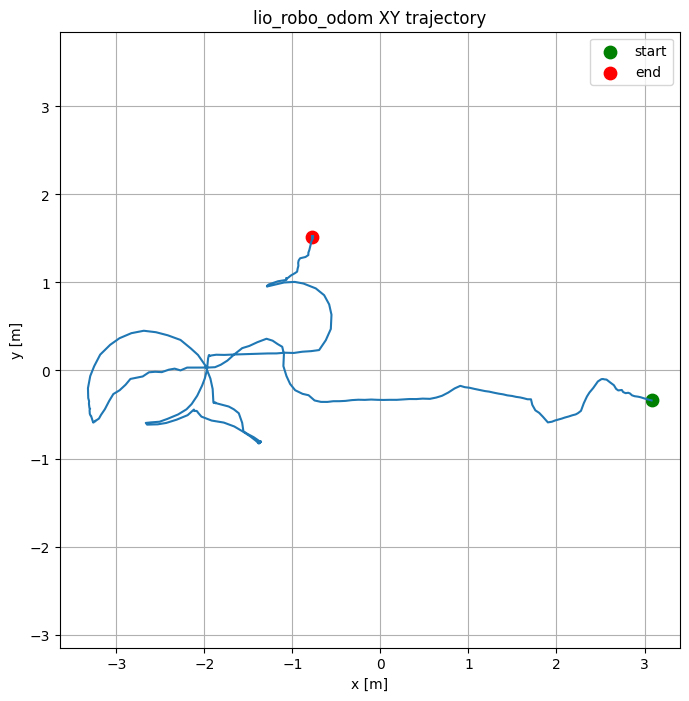

In [21]:
plt.figure(figsize=(8, 8))
plt.plot(x, y, linewidth=1.5)
plt.scatter(x[0], y[0], c="green", s=80, label="start")
plt.scatter(x[-1], y[-1], c="red", s=80, label="end")
plt.axis("equal")
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title(f"{odom_name} XY trajectory")
plt.legend()
plt.show()

## 6. XYZ 三维轨迹

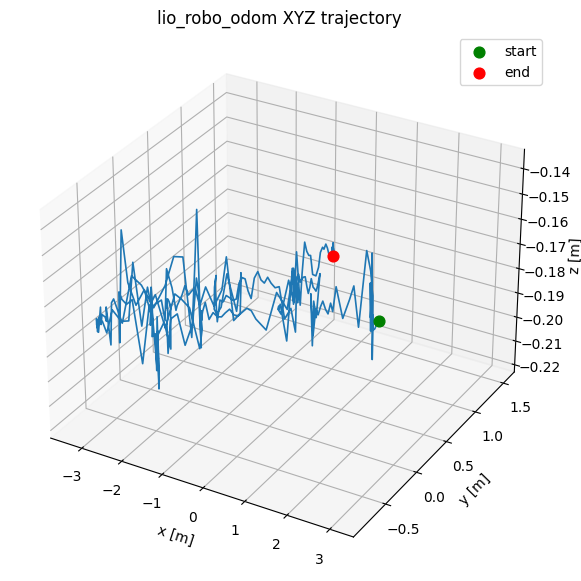

In [22]:
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")
ax.plot(x, y, z, linewidth=1.2)
ax.scatter(x[0], y[0], z[0], c="green", s=60, label="start")
ax.scatter(x[-1], y[-1], z[-1], c="red", s=60, label="end")
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_zlabel("z [m]")
ax.set_title(f"{odom_name} XYZ trajectory")
ax.legend()
plt.show()

## 7. 位置随样本编号变化

如果轨迹有跳变，这个图通常更容易定位异常点。

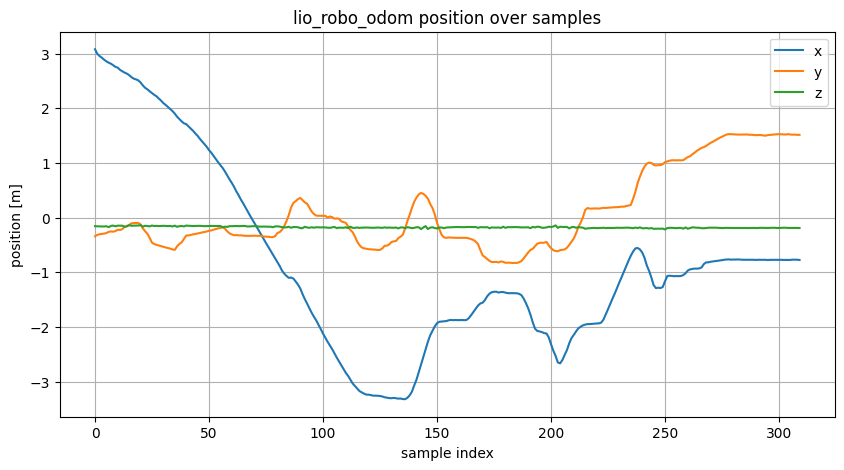

In [23]:
sample_idx = np.arange(len(x))

plt.figure(figsize=(10, 5))
plt.plot(sample_idx, x, label="x")
plt.plot(sample_idx, y, label="y")
plt.plot(sample_idx, z, label="z")
plt.xlabel("sample index")
plt.ylabel("position [m]")
plt.title(f"{odom_name} position over samples")
plt.legend()
plt.show()

## 8. 检查同步误差

`diff_ns` 是同步样本时间和最近 odom 时间之间的差值。默认处理脚本中 `--max-diff-sec` 是 0.2 秒。

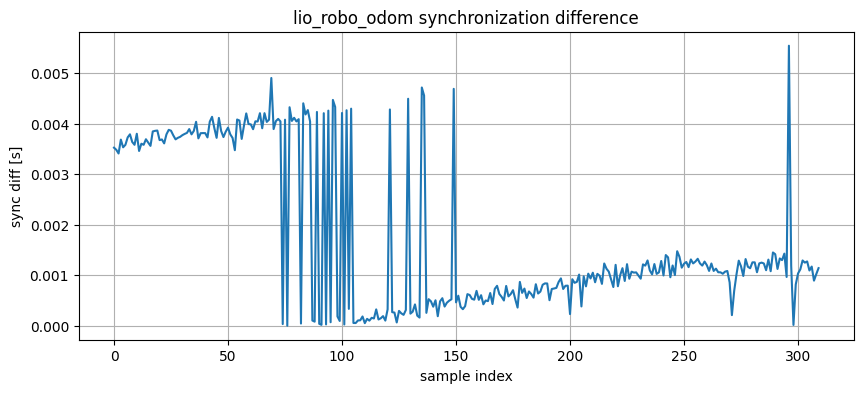

mean diff sec: 0.0017710660193548389
max diff sec : 0.005543228


In [24]:
diff_sec = odom["diff_ns"] / 1e9

plt.figure(figsize=(10, 4))
plt.plot(diff_sec)
plt.xlabel("sample index")
plt.ylabel("sync diff [s]")
plt.title(f"{odom_name} synchronization difference")
plt.show()

print("mean diff sec:", diff_sec.mean() if len(diff_sec) else None)
print("max diff sec :", diff_sec.max() if len(diff_sec) else None)

## 9. 同时比较 `/lio/odom` 和 `/lio/robo/odom`

如果两个文件都存在，可以把它们画在同一张图里。

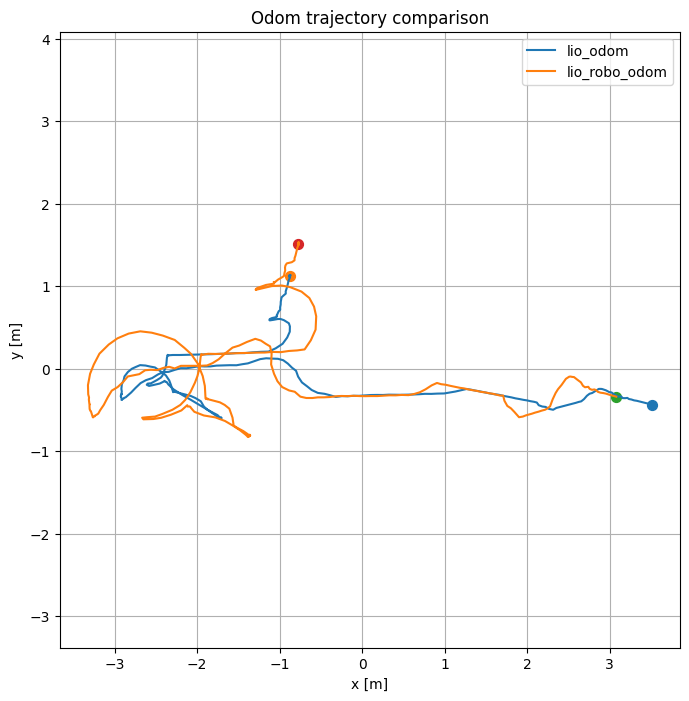

In [25]:
def xy_from_odom(name):
    item = load_odom_npz(DATASET_DIR, name)
    fields = item["fields"]
    data = item["data"]
    return data[:, fields.index("px")], data[:, fields.index("py")]

plt.figure(figsize=(8, 8))

for name in ["lio_odom", "lio_robo_odom"]:
    path = DATASET_DIR / f"{name}.npz"
    if not path.exists():
        print(f"skip missing {path}")
        continue
    xx, yy = xy_from_odom(name)
    plt.plot(xx, yy, label=name)
    plt.scatter(xx[0], yy[0], s=50)
    plt.scatter(xx[-1], yy[-1], s=50)

plt.axis("equal")
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title("Odom trajectory comparison")
plt.legend()
plt.show()

## 10. 可视化 DOA

这一部分读取 `compute_doa_from_odom.py` 生成的 `doa_*.npz`，在 XY 轨迹上标出若干采样点的 DOA。

- 蓝色箭头：机器人头方向，也就是麦克风/机器人 body `+x` 方向投影到水平面
- 橙色箭头：从机器人当前位置指向 target 的方向
- 文字：`heading_target_yaw_signed_deg`，也就是从蓝色箭头转到橙色箭头的水平有符号夹角

默认只标少量点，避免文字和轨迹重叠。

In [26]:
def load_doa_npz(dataset_dir, odom_name="lio_odom", output_prefix="doa"):
    path = dataset_dir / f"{output_prefix}_{odom_name}.npz"
    if not path.exists():
        raise FileNotFoundError(
            f"Missing {path}. Run compute_doa_from_odom.py first, for example:\n"
            f"python data_processing/compute_doa_from_odom.py --dataset {dataset_dir} --odom {odom_name}"
        )
    item = np.load(path, allow_pickle=False)
    fields = [str(x) for x in item["fields"]]
    return {
        "path": path,
        "fields": fields,
        "data": item["data"],
        "sample_ids": item["sample_ids"],
        "timestamps_ns": item["timestamps_ns"],
    }


doa_odom_name = "lio_odom"  # 可改成 "lio_robo_odom"
doa = load_doa_npz(DATASET_DIR, doa_odom_name)
doa_idx = {name: doa["fields"].index(name) for name in doa["fields"]}
doa_data = doa["data"]

robot_x = doa_data[:, doa_idx["robot_x"]]
robot_y = doa_data[:, doa_idx["robot_y"]]
target_x = doa_data[:, doa_idx["target_x"]]
target_y = doa_data[:, doa_idx["target_y"]]
heading_x = doa_data[:, doa_idx["heading_world_x"]]
heading_y = doa_data[:, doa_idx["heading_world_y"]]
target_vec_x = doa_data[:, doa_idx["target_vector_world_x"]]
target_vec_y = doa_data[:, doa_idx["target_vector_world_y"]]
yaw_signed = doa_data[:, doa_idx["heading_target_yaw_signed_deg"]]

print("path:", doa["path"])
print("fields:", doa["fields"])
print("data shape:", doa_data.shape)
print("yaw range:", yaw_signed.min(), yaw_signed.max())

path: /home/kemove/yyz/audio-nav/ws_col/synced_dataset/clock3/doa_lio_odom.npz
fields: ['robot_x', 'robot_y', 'source_odom_x', 'source_odom_y', 'target_x', 'target_y', 'target_vector_world_x', 'target_vector_world_y', 'heading_world_x', 'heading_world_y', 'distance_xy', 'robot_heading_world_deg', 'target_azimuth_world_deg', 'heading_target_yaw_signed_deg', 'heading_target_yaw_abs_deg']
data shape: (310, 15)
yaw range: -177.85458003716835 174.9323957647286


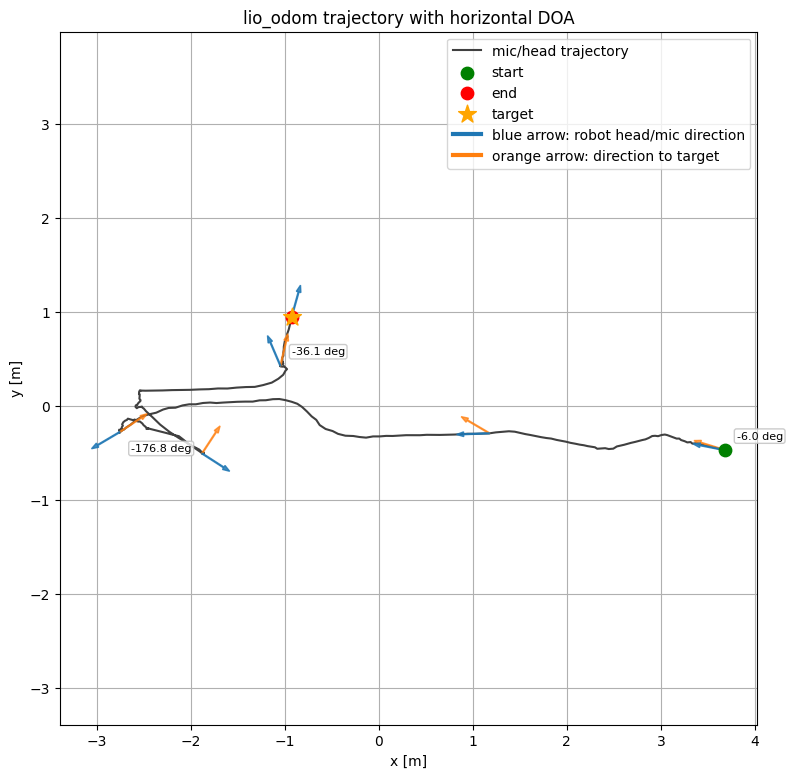

In [27]:
def normalize_xy(u, v):
    norm = np.hypot(u, v)
    if norm == 0:
        return 0.0, 0.0
    return u / norm, v / norm


num_markers = 6        # 图上标多少个点；越小越稀疏
arrow_length = 0.35    # 箭头长度，单位 m；如果轨迹尺度大，可以调大
label_every = 2        # 每几个 marker 标一次角度；越大文字越少

marker_indices = np.linspace(0, len(robot_x) - 1, min(num_markers, len(robot_x)), dtype=int)

plt.figure(figsize=(9, 9))
plt.plot(robot_x, robot_y, color="0.25", linewidth=1.5, label="mic/head trajectory")
plt.scatter(robot_x[0], robot_y[0], c="green", s=80, label="start", zorder=5)
plt.scatter(robot_x[-1], robot_y[-1], c="red", s=80, label="end", zorder=5)
plt.scatter(target_x[-1], target_y[-1], c="orange", marker="*", s=180, label="target", zorder=6)
plt.plot([], [], color="tab:blue", linewidth=3, label="blue arrow: robot head/mic direction")
plt.plot([], [], color="tab:orange", linewidth=3, label="orange arrow: direction to target")

for k, i in enumerate(marker_indices):
    hx, hy = normalize_xy(heading_x[i], heading_y[i])
    tx, ty = normalize_xy(target_vec_x[i], target_vec_y[i])

    plt.arrow(
        robot_x[i], robot_y[i],
        hx * arrow_length, hy * arrow_length,
        width=0.01,
        head_width=0.05,
        length_includes_head=True,
        color="tab:blue",
        alpha=0.85,
        zorder=4,
    )
    plt.arrow(
        robot_x[i], robot_y[i],
        tx * arrow_length, ty * arrow_length,
        width=0.01,
        head_width=0.05,
        length_includes_head=True,
        color="tab:orange",
        alpha=0.75,
        zorder=3,
    )

    if k % label_every == 0:
        offset = (8, 8) if (k // label_every) % 2 == 0 else (8, -14)
        plt.annotate(
            f"{yaw_signed[i]:.1f} deg",
            xy=(robot_x[i], robot_y[i]),
            xytext=offset,
            textcoords="offset points",
            fontsize=8,
            bbox={"boxstyle": "round,pad=0.2", "fc": "white", "ec": "0.75", "alpha": 0.8},
        )

plt.axis("equal")
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title(f"{doa_odom_name} trajectory with horizontal DOA")
plt.legend()
plt.show()

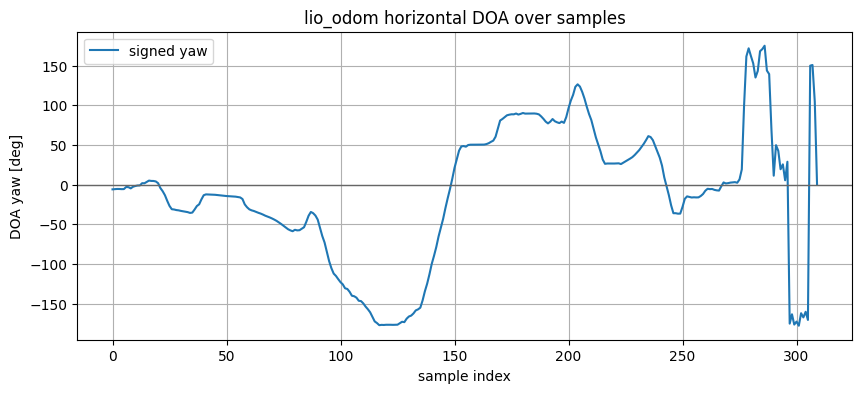

mean abs yaw: 65.35788913437904
max abs yaw : 177.85458003716835


In [28]:
sample_axis = np.arange(len(yaw_signed))

plt.figure(figsize=(10, 4))
plt.plot(sample_axis, yaw_signed, label="signed yaw")
plt.axhline(0.0, color="0.4", linewidth=1.0)
plt.xlabel("sample index")
plt.ylabel("DOA yaw [deg]")
plt.title(f"{doa_odom_name} horizontal DOA over samples")
plt.legend()
plt.show()

print("mean abs yaw:", np.mean(np.abs(yaw_signed)))
print("max abs yaw :", np.max(np.abs(yaw_signed)))